# Tile test: accuracy and classification time

Line plots for **concentric circles** and **plant tissue** from `test-results/tile-tests/`. The example cell overlays **IBM Marrakesh** (solid lines, round markers) and **Fake Marrakesh** (dashed lines, square markers) on the same axes.

**Mean-accuracy** line plots use vertical error bars from the CSV column `mean_accuracy_sem` (standard error of the mean over repeated pipeline iterations). Re-run the experiment CSV export if that column is missing.

Thanks CursorAI

In [ ]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, ScalarFormatter

# Load CSVs from repo root whether the kernel cwd is the project root or exploration_notebooks/
def _figures_output_dir() -> Path:
    """Use the thesis repo's ``figures/`` (same directory that holds ``exploration_notebooks/``)."""
    cwd = Path.cwd().resolve()
    if cwd.name == "exploration_notebooks":
        out = cwd.parent / "figures"
    else:
        out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out.resolve()


cwd = Path.cwd().resolve()
plot_dir = _figures_output_dir()
MEAN_ACCURACY_YLABEL = "Mean classification accuracy"

# Thesis-style figure titles (edit here for consistency with chapter captions)
TITLE_TILE_ACC = "Mean classification accuracy as a function of tile size"
TITLE_TILE_TIME = "Mean classification time as a function of tile size"
TITLE_SHOT_ACC = "Mean classification accuracy as a function of shot count"
TITLE_SHOT_TIME = "Mean classification time as a function of shot count"
TITLE_DEPTH_ACC = "Mean classification accuracy as a function of transpiled circuit depth"
TITLE_SYNTHETIC = "synthetic concentric circles test image"
TITLE_PLANT = "plant tissue test image"
TITLE_EX3_BACKENDS = "IBM Marrakesh, Miami, and Boston hardware with matched Fake noise models"
TITLE_EX2_BACKENDS = "Fake Torino vs. Aer simulator"
TILE_TIME_YCOL = "avg_classification_s"

def _load_tile_test_csv(filename: str) -> pd.DataFrame:
    cwd = Path.cwd().resolve()
    for root in (cwd, cwd.parent):
        path = root / filename
        if path.is_file():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find {filename} under {cwd} or {cwd.parent}. "
        "Open the notebook from the repo or set the kernel cwd to exploration_notebooks/."
    )


def _tile_edge_and_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[int], list[float]]:
    if ycol not in df.columns:
        raise KeyError(f"CSV missing column {ycol!r}; have {list(df.columns)}")
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].tolist(), tmp[ycol].astype(float).tolist()


def _tile_edge_mean_accuracy_series(
    df: pd.DataFrame,
) -> tuple[list[int], list[float], list[float] | None]:
    """Tile edge vs ``mean_accuracy``; optional ``mean_accuracy_sem`` (SEM across repeated iterations)."""
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    x = tmp["_edge"].tolist()
    y = tmp["mean_accuracy"].astype(float).tolist()
    if "mean_accuracy_sem" in tmp.columns:
        yerr = tmp["mean_accuracy_sem"].astype(float).tolist()
    else:
        yerr = None
    return x, y, yerr


def _shot_scale_mean_accuracy_series(
    df: pd.DataFrame,
) -> tuple[list[float], list[float], list[float] | None]:
    tmp = df.copy().sort_values("shot_scale_2_pow_k")
    x = tmp["shot_scale_2_pow_k"].astype(float).tolist()
    y = tmp["mean_accuracy"].astype(float).tolist()
    if "mean_accuracy_sem" in tmp.columns:
        yerr = tmp["mean_accuracy_sem"].astype(float).tolist()
    else:
        yerr = None
    return x, y, yerr


def _plot_mean_accuracy_line(
    ax: plt.Axes,
    x,
    y: list[float],
    yerr: list[float] | None,
    *,
    capsize: float = 3,
    **kwargs,
) -> None:
    """Line or errorbar plot for mean accuracy; uses error bars when ``yerr`` is provided."""
    if yerr is not None:
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            capsize=capsize,
            elinewidth=1,
            **kwargs,
        )
    else:
        ax.plot(x, y, **kwargs)


def _apply_tile_xaxis_log2(ax: plt.Axes, edges: set[int]) -> None:
    """Use log₂ x so equal ratios of tile edge (2→4→8→…) get equal visual spacing."""
    if not edges:
        return
    lo, hi = min(edges), max(edges)
    # Label every power-of-two between min and max (e.g. 32 between 16 and 64).
    lo_exp = lo.bit_length() - 1
    hi_exp = hi.bit_length() - 1
    ticks = [1 << k for k in range(lo_exp, hi_exp + 1)]
    ax.set_xscale("log", base=2)
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(NullLocator())


def plot_mean_accuracy(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = TITLE_TILE_ACC,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y, yerr = _tile_edge_mean_accuracy_series(df)
        _plot_mean_accuracy_line(
            ax, x, y, yerr, marker="o", linewidth=2, label=lab, color=color
        )

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _tile_edges = set(_tile_edge_and_sorted(circle_df, "mean_accuracy")[0]) | set(
        _tile_edge_and_sorted(plant_df, "mean_accuracy")[0]
    )
    _apply_tile_xaxis_log2(ax, _tile_edges)
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = TITLE_TILE_TIME,
    ycol: str = TILE_TIME_YCOL,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of ``avg_classification_s`` (quantum classification only, not total pipeline time)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, ycol)
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _tile_edges = set(_tile_edge_and_sorted(circle_df, ycol)[0]) | set(
        _tile_edge_and_sorted(plant_df, ycol)[0]
    )
    _apply_tile_xaxis_log2(ax, _tile_edges)
    fig.tight_layout()
    return fig, ax


def _unpack_tile_overlay_row(
    row: tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str],
) -> tuple[pd.DataFrame, str, str, str, str]:
    """(df, label, color, linestyle) or add optional ``marker`` (``o`` = hardware, ``s`` = fake).

    If marker is omitted: solid ``-`` → round ``o``; any other linestyle → square ``s``.
    """
    if len(row) == 5:
        df, lab, color, ls, mk = row
        return df, lab, color, ls, mk
    df, lab, color, ls = row
    mk = "o" if ls.strip() == "-" else "s"
    return df, lab, color, ls, mk


def plot_mean_accuracy_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = TITLE_TILE_ACC,
) -> tuple[plt.Figure, plt.Axes]:
    """Multiple overlays; each row is (df, label, color, linestyle) or (... , marker)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y, yerr = _tile_edge_mean_accuracy_series(df)
        all_edges.update(x)
        _plot_mean_accuracy_line(
            ax,
            x,
            y,
            yerr,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _apply_tile_xaxis_log2(ax, all_edges)
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = TITLE_TILE_TIME,
    ycol: str = TILE_TIME_YCOL,
) -> tuple[plt.Figure, plt.Axes]:
    """Same series rows as ``plot_mean_accuracy_multi``; y is ``avg_classification_s`` from each CSV."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y = _tile_edge_and_sorted(df, ycol)
        all_edges.update(x)
        ax.plot(
            x,
            y,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    _apply_tile_xaxis_log2(ax, all_edges)
    fig.tight_layout()
    return fig, ax


def _shot_scale_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[float], list[float]]:
    """Sort by ``shot_scale_2_pow_k`` (2**k) for line plots vs shot budget."""
    tmp = df.copy()
    tmp = tmp.sort_values("shot_scale_2_pow_k")
    return (
        tmp["shot_scale_2_pow_k"].astype(float).tolist(),
        tmp[ycol].astype(float).tolist(),
    )


def plot_mean_accuracy_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = TITLE_SHOT_ACC,
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y, yerr = _shot_scale_mean_accuracy_series(df)
        _plot_mean_accuracy_line(
            ax, x, y, yerr, marker="o", linewidth=2, label=lab, color=color
        )

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "mean_accuracy")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = TITLE_SHOT_TIME,
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y = _shot_scale_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "avg_classification_s")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_synthetic_tile_test_depth_vs_mean_accuracy.png


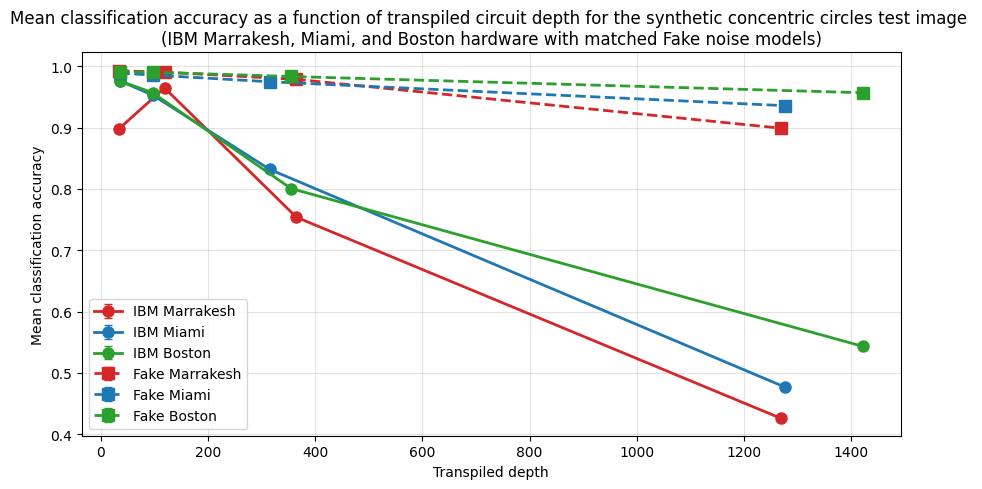

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_plant_tile_test_depth_vs_mean_accuracy.png


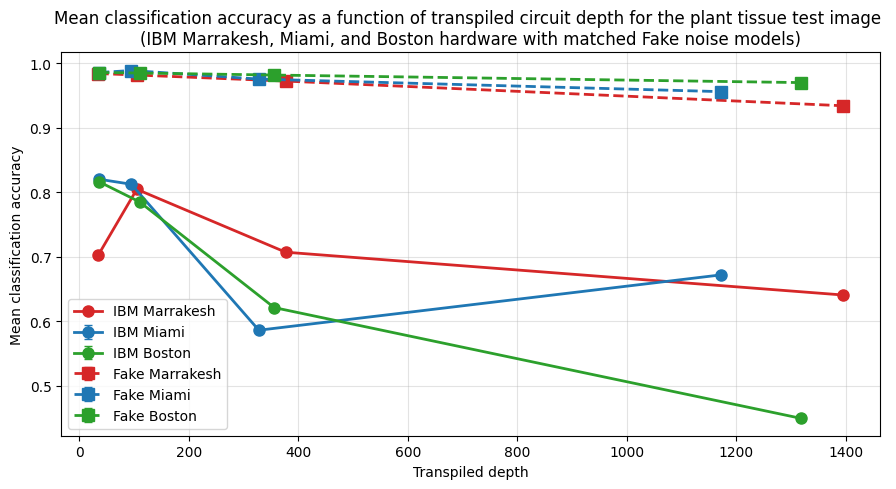

In [3]:
# Depth vs accuracy (transpiled depth from JobOutputs JSON, mean accuracy from tile-test CSV)
# Assumes 16x16 images => n_tiles = (16 / tile_edge)^2
import json

JOB_INFO_PATH = "../JobOutputs/job_submission_info.json"
JOB_OUTPUTS_DIR = Path("../JobOutputs")

job_info = json.loads(Path(JOB_INFO_PATH).read_text(encoding="utf-8"))

# job_submission_info has separate circle vs plant records (depths can differ).
_job_image_kind: dict[str, str] = {}
for _results_path in JOB_OUTPUTS_DIR.rglob("job_results_*.json"):
    _parts = _results_path.parts
    if "circle" in _parts:
        _kind = "circle"
    elif "plant" in _parts:
        _kind = "plant"
    else:
        continue
    _job_image_kind[_results_path.stem.removeprefix("job_results_")] = _kind


def _expected_n_tiles(tile_edge: int, full_edge: int = 16) -> int:
    if full_edge % tile_edge != 0:
        raise ValueError(f"full_edge={full_edge} not divisible by tile_edge={tile_edge}")
    return (full_edge // tile_edge) ** 2


# IBM hardware depths from JobOutputs; fake backends use matching IBM model depths.
_DEPTH_BACKEND_BY_LABEL = {
    "IBM Marrakesh": "ibm_marrakesh",
    "IBM Miami": "ibm_miami",
    "IBM Boston": "ibm_boston",
    "Fake Marrakesh": "ibm_marrakesh",
    "Fake Miami": "ibm_miami",
    "Fake Boston": "ibm_boston",
}


def _depth_for_tile_edge(
    tile_edge: int,
    backend_name: str,
    *,
    image_kind: str,
) -> int:
    want_n_tiles = _expected_n_tiles(tile_edge)

    for job_id, rec in job_info.items():
        if _job_image_kind.get(job_id) != image_kind:
            continue
        if rec.get("backend_name") != backend_name:
            continue
        if (
            rec.get("tile_width") == tile_edge
            and rec.get("tile_height") == tile_edge
            and rec.get("n_tiles") == want_n_tiles
        ):
            return int(rec["transpiled_depth"])

    for job_id, rec in job_info.items():
        if _job_image_kind.get(job_id) != image_kind:
            continue
        if rec.get("backend_name") != backend_name:
            continue
        if rec.get("tile_width") == tile_edge and rec.get("tile_height") == tile_edge:
            return int(rec["transpiled_depth"])

    raise KeyError(
        f"No job for backend={backend_name!r}, image_kind={image_kind!r}, tile_edge={tile_edge}"
    )


def _depth_vs_accuracy_points(
    df: pd.DataFrame,
    backend_name: str,
    *,
    image_kind: str,
) -> tuple[list[int], list[float], list[float] | None]:
    edges, acc, acc_sem = _tile_edge_mean_accuracy_series(df)
    depths = [_depth_for_tile_edge(e, backend_name, image_kind=image_kind) for e in edges]
    return depths, acc, acc_sem


def _sort_depth_accuracy(
    depths: list[int],
    acc: list[float],
    acc_sem: list[float] | None,
) -> tuple[list[int], list[float], list[float] | None]:
    if acc_sem is None:
        pairs = sorted(zip(depths, acc))
        x_s, y_s = (list(t) for t in zip(*pairs))
        return x_s, y_s, None
    pairs = sorted(zip(depths, acc, acc_sem))
    x_s, y_s, err_s = (list(t) for t in zip(*pairs))
    return x_s, y_s, err_s


def plot_depth_vs_mean_accuracy_multi(
    series: list[tuple[pd.DataFrame, str, str, str]],
    *,
    title: str,
    image_kind: str,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(9, 5))
    for df, lab, color, ls in series:
        backend_name = _DEPTH_BACKEND_BY_LABEL[lab]
        mk = "o" if ls.strip() == "-" else "s"
        x, y, yerr = _depth_vs_accuracy_points(df, backend_name, image_kind=image_kind)
        x_s, y_s, yerr_s = _sort_depth_accuracy(x, y, yerr)
        _plot_mean_accuracy_line(
            ax,
            x_s,
            y_s,
            yerr_s,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Transpiled depth")
    ax.set_ylabel(MEAN_ACCURACY_YLABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)
    ax.legend()
    fig.tight_layout()
    return fig, ax


# Same CSVs as ex3 tile-test plots (IBM hardware + matching fakes).
EX3_DIR = "../test-results/tile-tests/ex3"
BACKEND_COLORS = ("#d62728", "#1f77b4", "#2ca02c")

_ex3_synthetic_depth_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/circle_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/circle_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/circle_16x16_method_1_iso_0_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/circle_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/circle_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

_ex3_plant_depth_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/plant_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/plant_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/plant_2_16x16_method_1_iso-0.5_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/plant_2_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/plant_2_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

for _label, _series, _stem, _kind in (
    ("Synthetic", _ex3_synthetic_depth_series, "ex3_synthetic", "circle"),
    ("Plant", _ex3_plant_depth_series, "ex3_plant", "plant"),
):
    fig, _ = plot_depth_vs_mean_accuracy_multi(
        _series,
        title=(
            f"{TITLE_DEPTH_ACC} for the {TITLE_SYNTHETIC if _kind == 'circle' else TITLE_PLANT} "
            f"\n({TITLE_EX3_BACKENDS})"
        ),
        image_kind=_kind,
    )
    out_path = plot_dir / f"{_stem}_tile_test_depth_vs_mean_accuracy.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path.resolve()}")
    plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex2\fake_torino_vs_aer_tile_test_mean_accuracy.png


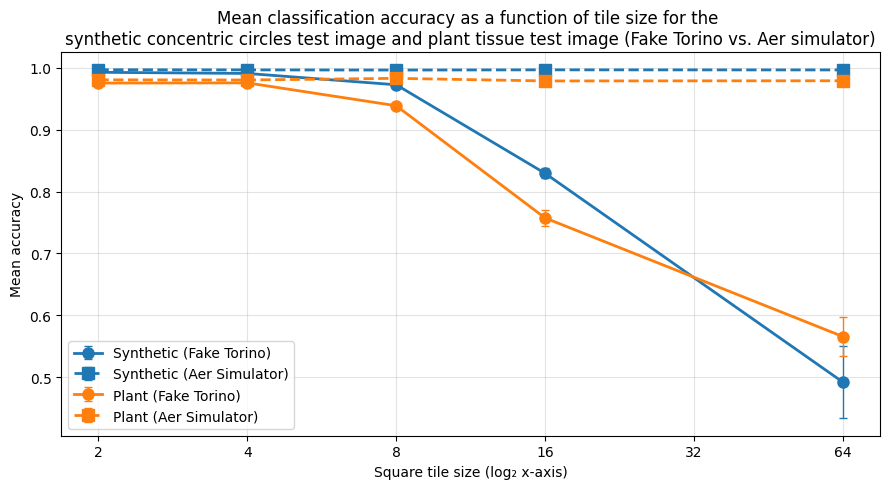

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex2\fake_torino_vs_aer_tile_test_avg_classification_s.png


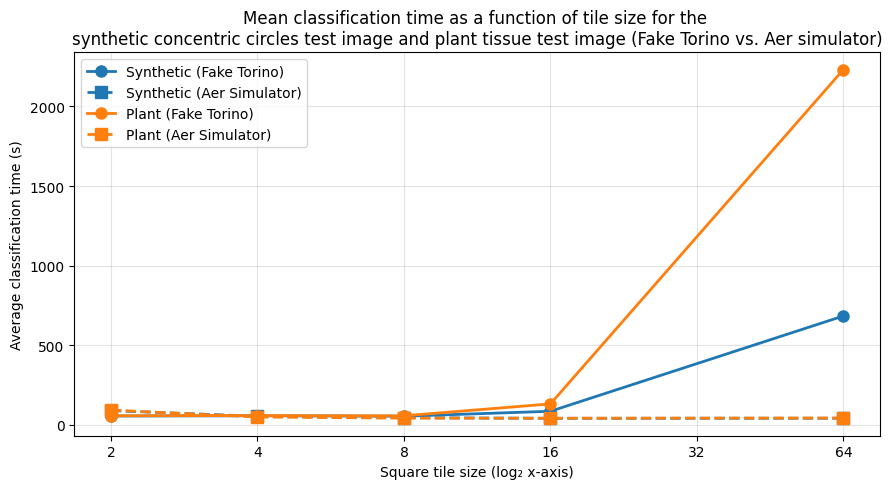

In [4]:
COLORS = ("#1f77b4", "#ff7f0e")
EX2_TILE_DIR = "../test-results/tile-tests"
ex2_plot_dir = plot_dir / "ex2"
ex2_plot_dir.mkdir(parents=True, exist_ok=True)

circle_torino = _load_tile_test_csv(
    f"{EX2_TILE_DIR}/torino/circle_64x64_method_1_iso_0_torino_sc12_results.csv"
)
plant_torino = _load_tile_test_csv(
    f"{EX2_TILE_DIR}/torino/plant_2_64x64_method_1_iso-0.5_torino_sc12_results.csv"
)
circle_aer = _load_tile_test_csv(
    f"{EX2_TILE_DIR}/aer/circle_64x64_method_1_iso_0_aer_sc12_results.csv"
)
plant_aer = _load_tile_test_csv(
    f"{EX2_TILE_DIR}/aer/plant_2_64x64_method_1_iso-0.5_aer_sc12_results.csv"
)

_acc_series = [
    (circle_torino, "Synthetic (Fake Torino)", COLORS[0], "-"),
    (circle_aer, "Synthetic (Aer Simulator)", COLORS[0], "--"),
    (plant_torino, "Plant (Fake Torino)", COLORS[1], "-"),
    (plant_aer, "Plant (Aer Simulator)", COLORS[1], "--")
]

fig_acc, _ = plot_mean_accuracy_multi(
    _acc_series,
    title=f"{TITLE_TILE_ACC} for the \n{TITLE_SYNTHETIC} and {TITLE_PLANT} ({TITLE_EX2_BACKENDS})",
)
acc_path = ex2_plot_dir / "fake_torino_vs_aer_tile_test_mean_accuracy.png"
fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {acc_path.resolve()}")
plt.show()

fig_time, _ = plot_avg_classification_s_multi(
    _acc_series,
    ycol=TILE_TIME_YCOL,
    title=f"{TITLE_TILE_TIME} for the \n{TITLE_SYNTHETIC} and {TITLE_PLANT} ({TITLE_EX2_BACKENDS})",
)
time_path = ex2_plot_dir / "fake_torino_vs_aer_tile_test_avg_classification_s.png"
fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {time_path.resolve()}")
plt.show()



Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_synthetic_tile_test_mean_accuracy.png


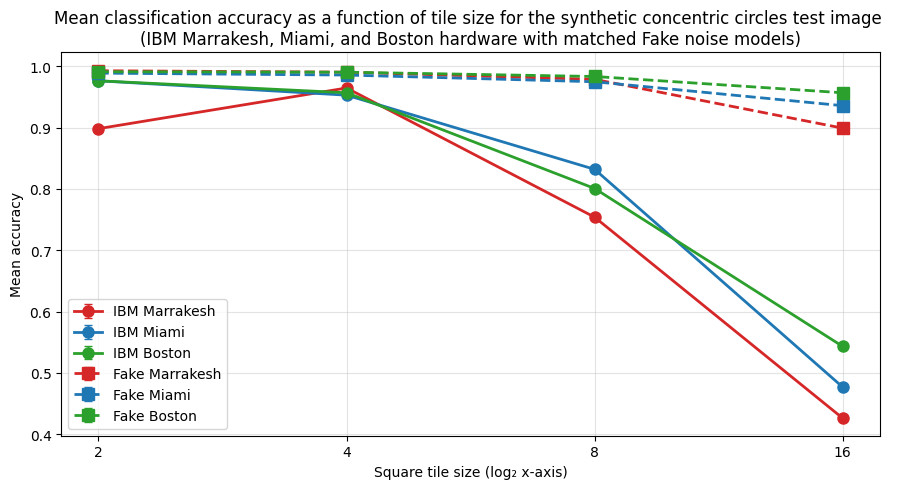

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_synthetic_tile_test_avg_classification_s.png


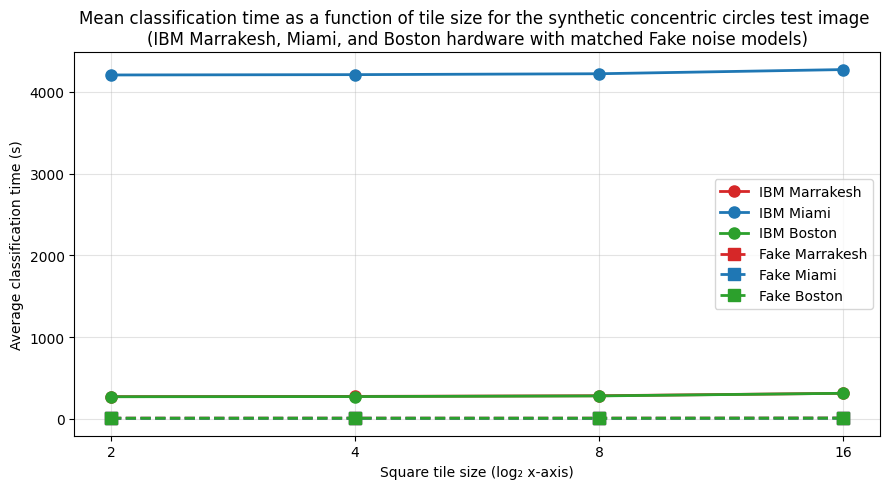

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_plant_tile_test_mean_accuracy.png


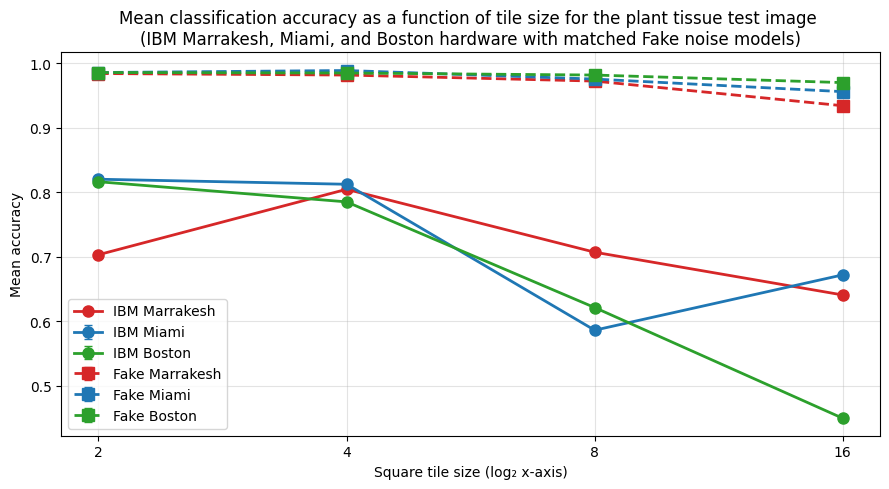

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\ex3_plant_tile_test_avg_classification_s.png


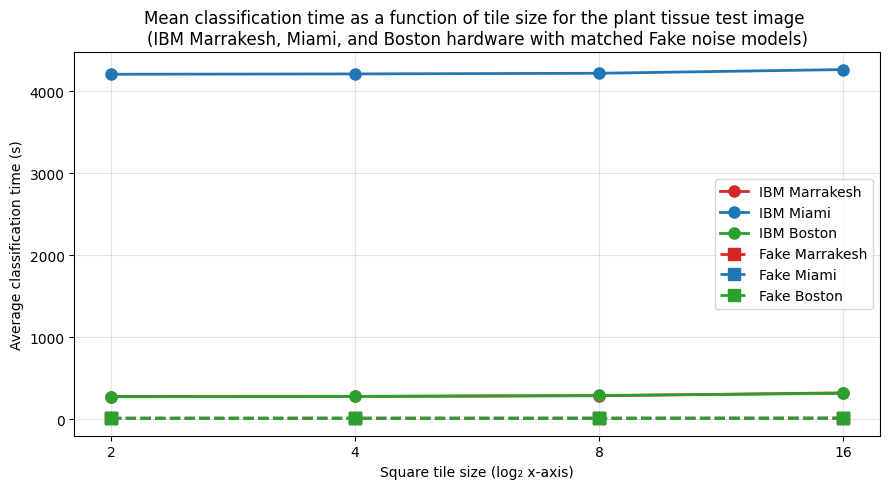

In [5]:
# ex3 tile test: IBM Marrakesh, Miami, and Boston (solid) vs matching fakes (dashed)
# Synthetic and plant each get their own accuracy + classification-time figure.
EX3_DIR = "../test-results/tile-tests/ex3"
BACKEND_COLORS = ("#d62728", "#1f77b4", "#2ca02c")  # Marrakesh (red), Miami (blue), Boston (green)

_ex3_synthetic_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/circle_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/circle_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/circle_16x16_method_1_iso_0_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/circle_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/circle_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

_ex3_plant_series = [
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv"),
        "IBM Marrakesh",
        BACKEND_COLORS[0],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-miami/plant_miami_hw_sc12_results.csv"),
        "IBM Miami",
        BACKEND_COLORS[1],
        "-",
    ),
    (
        _load_tile_test_csv(f"{EX3_DIR}/ibm-boston/plant_boston_hw_sc12_results.csv"),
        "IBM Boston",
        BACKEND_COLORS[2],
        "-",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/marrakesh/plant_2_16x16_method_1_iso-0.5_marrakesh_sc12_results.csv"
        ),
        "Fake Marrakesh",
        BACKEND_COLORS[0],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/miami/plant_2_16x16_method_1_iso_0_miami_sc12_results.csv"
        ),
        "Fake Miami",
        BACKEND_COLORS[1],
        "--",
    ),
    (
        _load_tile_test_csv(
            f"{EX3_DIR}/boston/plant_2_16x16_method_1_iso_0_boston_sc12_results.csv"
        ),
        "Fake Boston",
        BACKEND_COLORS[2],
        "--",
    ),
]

for _label, _series, _stem in (
    ("Synthetic", _ex3_synthetic_series, "ex3_synthetic"),
    ("Plant", _ex3_plant_series, "ex3_plant"),
):
    fig_acc, _ = plot_mean_accuracy_multi(
        _series,
        title=(
            f"{TITLE_TILE_ACC} for the "
            f"{TITLE_SYNTHETIC if _label == 'Synthetic' else TITLE_PLANT} \n({TITLE_EX3_BACKENDS})"
        ),
    )
    acc_path = plot_dir / f"{_stem}_tile_test_mean_accuracy.png"
    fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {acc_path.resolve()}")
    plt.show()

    fig_time, _ = plot_avg_classification_s_multi(
        _series,
        title=(
            f"{TITLE_TILE_TIME} for the "
            f"{TITLE_SYNTHETIC if _label == 'Synthetic' else TITLE_PLANT} \n({TITLE_EX3_BACKENDS})"
        ),
    )
    time_path = plot_dir / f"{_stem}_tile_test_avg_classification_s.png"
    fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {time_path.resolve()}")
    plt.show()


Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\iso_weight_enc_shot_count_mean_accuracy.png


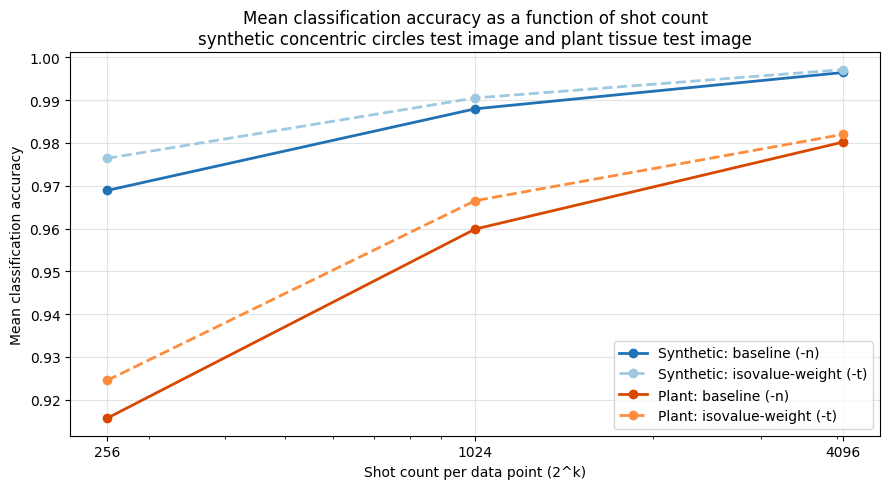

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\iso_weight_enc_shot_count_avg_classification_s.png


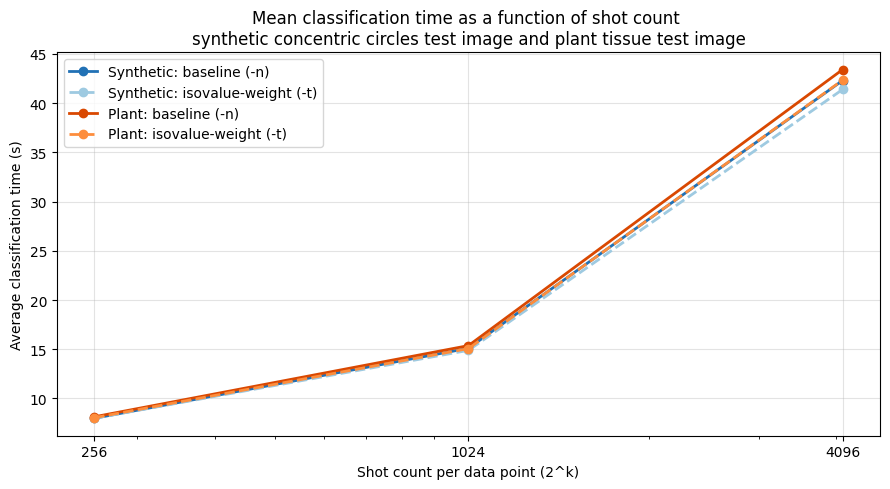

In [7]:
# 64×64 iso-weight encoding: shot count vs accuracy & classification time
# Circle + plant on each chart; baseline (-n) vs isovalue-weight (-t).
ISO_WEIGHT_DIR = "../test-results/iso-weight-enc"

_iso_shot_series = (
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/circle_64x64_method_1_iso-0.5-n_results.csv"),
        "Synthetic: baseline (-n)",
        "#2171b5",
        "-",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/circle_64x64_method_1_iso-0.5-t_results.csv"),
        "Synthetic: isovalue-weight (-t)",
        "#9ecae1",
        "--",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/plant_2_64x64_method_1_iso-0.5-n_results.csv"),
        "Plant: baseline (-n)",
        "#d94801",
        "-",
    ),
    (
        _load_tile_test_csv(f"{ISO_WEIGHT_DIR}/plant_2_64x64_method_1_iso-0.5-t_results.csv"),
        "Plant: isovalue-weight (-t)",
        "#fd8d3c",
        "--",
    ),
)

_shot_x_all = sorted(
    set()
    .union(*(_shot_scale_sorted(df, "mean_accuracy")[0] for df, _, _, _ in _iso_shot_series))
    .union(*(_shot_scale_sorted(df, "avg_classification_s")[0] for df, _, _, _ in _iso_shot_series))
)

fig_iso_acc, ax_iso_acc = plt.subplots(figsize=(9, 5))
for df, lab, color, ls in _iso_shot_series:
    x, y, yerr = _shot_scale_mean_accuracy_series(df)
    _plot_mean_accuracy_line(
        ax_iso_acc, x, y, yerr, marker="o", linewidth=2, label=lab, color=color, linestyle=ls
    )
ax_iso_acc.set_xlabel("Shot count per data point (2^k)")
ax_iso_acc.set_ylabel(MEAN_ACCURACY_YLABEL)
ax_iso_acc.set_title(
    f"{TITLE_SHOT_ACC}"
    f"\n{TITLE_SYNTHETIC} and {TITLE_PLANT}"
)
ax_iso_acc.legend()
ax_iso_acc.grid(True, alpha=0.35)
ax_iso_acc.set_xscale("log")
ax_iso_acc.set_xticks(_shot_x_all)
ax_iso_acc.get_xaxis().set_major_formatter(ScalarFormatter())
fig_iso_acc.tight_layout()
_iso_acc_path = plot_dir / "iso_weight_enc_shot_count_mean_accuracy.png"
fig_iso_acc.savefig(_iso_acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {_iso_acc_path.resolve()}")
plt.show()

fig_iso_time, ax_iso_time = plt.subplots(figsize=(9, 5))
for df, lab, color, ls in _iso_shot_series:
    x, y = _shot_scale_sorted(df, "avg_classification_s")
    ax_iso_time.plot(x, y, marker="o", linewidth=2, label=lab, color=color, linestyle=ls)
ax_iso_time.set_xlabel("Shot count per data point (2^k)")
ax_iso_time.set_ylabel("Average classification time (s)")
ax_iso_time.set_title(
    f"{TITLE_SHOT_TIME} "
    f"\n{TITLE_SYNTHETIC} and {TITLE_PLANT}"
)
ax_iso_time.legend()
ax_iso_time.grid(True, alpha=0.35)
ax_iso_time.set_xscale("log")
ax_iso_time.set_xticks(_shot_x_all)
ax_iso_time.get_xaxis().set_major_formatter(ScalarFormatter())
fig_iso_time.tight_layout()
_iso_time_path = plot_dir / "iso_weight_enc_shot_count_avg_classification_s.png"
fig_iso_time.savefig(_iso_time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {_iso_time_path.resolve()}")
plt.show()
